In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.linear_model import Lasso, OrthogonalMatchingPursuit
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler


In [2]:
# ======================================================
# 1. LOAD DATA
# ======================================================

X_emb = np.load("./data/mnist_emb_model1.npy")  # (N, d)
X_emb = StandardScaler().fit_transform(X_emb)
X_emb = X_emb[:2000].T  # -> (d, N)

d, N = X_emb.shape
n_atoms = 256

print("Data shape:", X_emb.shape)

Data shape: (128, 2000)


In [3]:
X_emb[0, :].mean()

0.00042940807

In [4]:
# ======================================================
# 2. INITIAL DICTIONARY
# ======================================================

def normalize_columns(D):
    return D / (np.linalg.norm(D, axis=0, keepdims=True) + 1e-8)

D_init = normalize_columns(np.random.randn(d, n_atoms))

In [5]:
def compute_metrics(X, D, R, name=""):
    X_hat = D @ R  # (d, N)

    errors = (
        np.linalg.norm(X - X_hat, axis=0) /
        np.linalg.norm(X, axis=0)
    ) * 100

    sparsity = np.sum(np.abs(R) > 1e-4, axis=0)
    sparsity_ratio = np.mean(np.abs(R) > 1e-4)

    print(f"\n===== {name} =====")
    print(f"Avg error: {errors.mean():.4f}")
    print(f"Std error: {errors.std():.4f}")
    print(f"Avg sparsity: {sparsity.mean():.2f}")
    print(f"Sparsity ratio: {sparsity_ratio:.4f}")

    return errors, sparsity


In [7]:
import torch
import numpy as np
from utils import SingleUserADMMDict


# ----------------------------
# Synthetic data
# ----------------------------
np.random.seed(0)
torch.manual_seed(0)

d = X_emb.shape[0]
n = X_emb.shape[1]
K = int(X_emb.shape[0] * 3.0)
k_sparsity = int(d * 0.1)


# ----------------------------
# Train model
# ----------------------------
model = SingleUserADMMDict(
    d=d,
    K=K,
    k_sparsity=k_sparsity,
    rho=5,
    admm_iters=30
)

X_emb_tensor = torch.from_numpy(X_emb).float()


D_hat, S_hat, losses = model.fit(X_emb_tensor, outer_iters=100)


# ----------------------------
# Evaluation
# ----------------------------
print("\nFinal loss:", losses[-1])

print("\nSparsity check (active atoms):")
active = torch.sum(torch.norm(S_hat, dim=1) > 1e-6).item()
print("Active atoms:", active, "/", K)


iter 0: loss=389.259125
iter 1: loss=52.213028
iter 2: loss=36.263908
iter 3: loss=34.883152
iter 4: loss=34.284779
iter 5: loss=33.945015
iter 6: loss=33.727421
iter 7: loss=33.577305
iter 8: loss=33.467606
iter 9: loss=33.384647
iter 10: loss=33.319923
iter 11: loss=33.267761
iter 12: loss=33.225273
iter 13: loss=33.189934
iter 14: loss=33.160057
iter 15: loss=33.134819
iter 16: loss=33.112686
iter 17: loss=33.093544
iter 18: loss=33.077080
iter 19: loss=33.062374
iter 20: loss=33.049267
iter 21: loss=33.037682
iter 22: loss=33.027100
iter 23: loss=33.017693
iter 24: loss=33.009144
iter 25: loss=33.001392
iter 26: loss=32.994377
iter 27: loss=32.987812
iter 28: loss=32.981968
iter 29: loss=32.976292
iter 30: loss=32.971222
iter 31: loss=32.966686
iter 32: loss=32.962246
iter 33: loss=32.958218
iter 34: loss=32.954342
iter 35: loss=32.950893
iter 36: loss=32.947586
iter 37: loss=32.944481
iter 38: loss=32.941463
iter 39: loss=32.938797
iter 40: loss=32.936214
iter 41: loss=32.933834
i

In [8]:
print((D_hat.T @ D_hat).sum())
print(k_sparsity)

tensor(12.0276)
12


In [9]:

eps = 1e-4

row_nnz = torch.sum(torch.abs(S_hat) > eps, dim=1)
row_sparsity_ratio = row_nnz.float() / S_hat.shape[1]
print(torch.sum(row_nnz > 0))
print(torch.sum(row_sparsity_ratio))

tensor(12)
tensor(12.)


In [ ]:

X_np = X_emb_tensor.detach().cpu().numpy()
D_np = D_hat.detach().cpu().numpy()
R_np = S_hat.detach().cpu().numpy()

errors, sparsity = compute_metrics(
    X_np,
    D_np,
    R_np,
    name="Admm"
)



===== Admm =====
Avg error: 6.6327
Std error: 1.6882
Avg sparsity: 12.00
Sparsity ratio: 0.0312


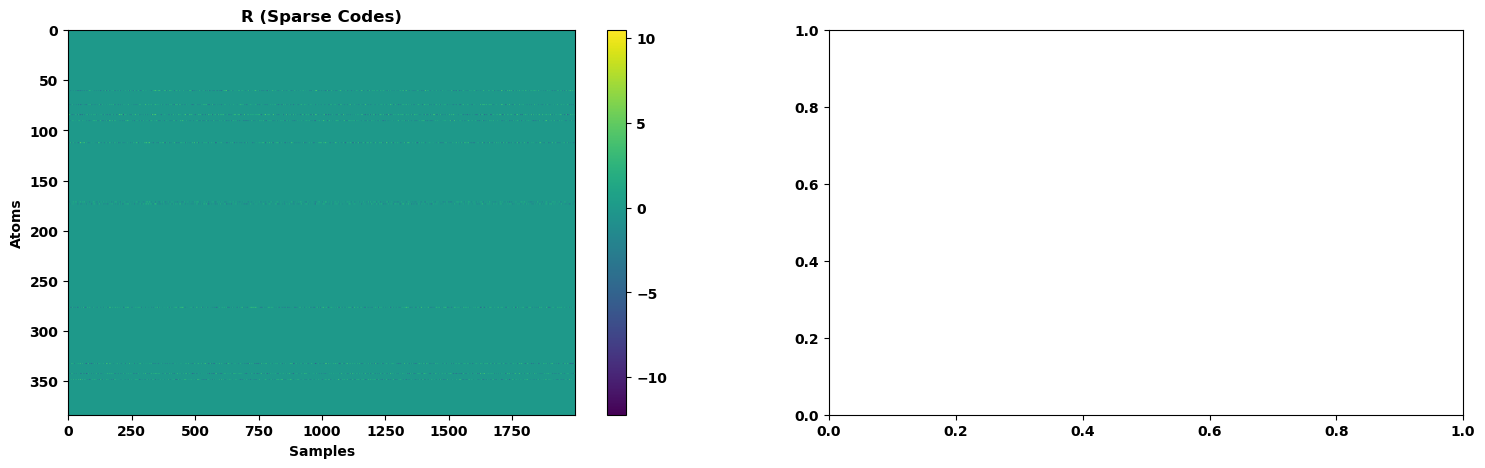

In [11]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Sparse codes
im0 = axes[0].imshow(S_hat, aspect="auto", cmap="viridis")
axes[0].set_title("R (Sparse Codes)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Atoms")
plt.colorbar(im0, ax=axes[0])



In [15]:
data_dir = "./data/"
X1 = np.load(data_dir + "mnist_emb_model1.npy")
X2 = np.load(data_dir + "mnist_emb_model2.npy")
X3 = np.load(data_dir + "mnist_emb_model3.npy")


X_1 = StandardScaler().fit_transform(X1)
X_1 = X_1[:2000]  # -> (d, N)
X_2 = StandardScaler().fit_transform(X2)
X_2 = X_2[:2000]  # -> (d, N)
X_3 = StandardScaler().fit_transform(X3)
X_3 = X_3[:2000]  # -> (d, N)

d, N = X_1.shape
K = int(X_1.shape[0] * 3.0)
k_sparsity = int(d * 0.1)

print(f"d: {d}, N: {N}, K: {K}, k_sparsity: {k_sparsity}")
print("Data shape:", X_1.shape, X_2.shape, X_3.shape)



X_dict = {
    0: torch.tensor(X_1.T).float(),  # (d x n)
    1: torch.tensor(X_2.T).float(),
    2: torch.tensor(X_3.T).float()
}

d: 2000, N: 128, K: 6000, k_sparsity: 200
Data shape: (2000, 128) (2000, 128) (2000, 128)


In [ ]:
from utils import MultiUserADMMDict

d = X1.shape[1]   # embedding dimension
K = int(X_emb.shape[0] * 2.0)           # number of atoms
k_sparsity = int(d * 0.9)   # number of active atoms

model = MultiUserADMMDict(
    d=d,
    K=n_atoms,
    k_sparsity=k_sparsity,
    rho=1.0,
    admm_iters=30
)

In [36]:
D, S_list, losses = model.fit(X_dict, outer_iters=100)

iter 0: loss=6304.037109
iter 1: loss=1077.965820
iter 2: loss=622.227417
iter 3: loss=277.949188
iter 4: loss=176.972534
iter 5: loss=176.358154
iter 6: loss=155.382111
iter 7: loss=140.429886
iter 8: loss=138.628220
iter 9: loss=131.759644
iter 10: loss=150.399872
iter 11: loss=128.280060
iter 12: loss=116.346626
iter 13: loss=130.655701
iter 14: loss=121.484566
iter 15: loss=137.688782
iter 16: loss=163.269943
iter 17: loss=221.108673
iter 18: loss=141.713730
iter 19: loss=135.489960
iter 20: loss=129.889587
iter 21: loss=119.005630
iter 22: loss=110.277512
iter 23: loss=109.180939
iter 24: loss=105.876572
iter 25: loss=102.701599
iter 26: loss=99.806519
iter 27: loss=98.542084
iter 28: loss=96.840057
iter 29: loss=108.970207
iter 30: loss=97.399895
iter 31: loss=95.546906
iter 32: loss=93.915428
iter 33: loss=104.794937
iter 34: loss=117.455353
iter 35: loss=117.862198
iter 36: loss=140.049683
iter 37: loss=122.827103
iter 38: loss=108.923515
iter 39: loss=103.247215
iter 40: loss=

In [37]:
X_np = X_dict[2].detach().cpu().numpy()
D_np = D.detach().cpu().numpy()
R_np = S_list[2].detach().cpu().numpy()

errors, sparsity = compute_metrics(
    X_np,
    D_np,
    R_np,
    name="Admm"
)


===== Admm =====
Avg error: 1.1955
Std error: 0.1860
Avg sparsity: 101.99
Sparsity ratio: 0.3984


In [38]:

eps = 1e-4

row_nnz = torch.sum(torch.abs(S_list[2]) > eps, dim=1)
row_sparsity_ratio = row_nnz.float() / S_list[2].shape[1]
print(torch.sum(row_nnz > 0))
print(torch.sum(row_sparsity_ratio))

tensor(102)
tensor(101.9930)


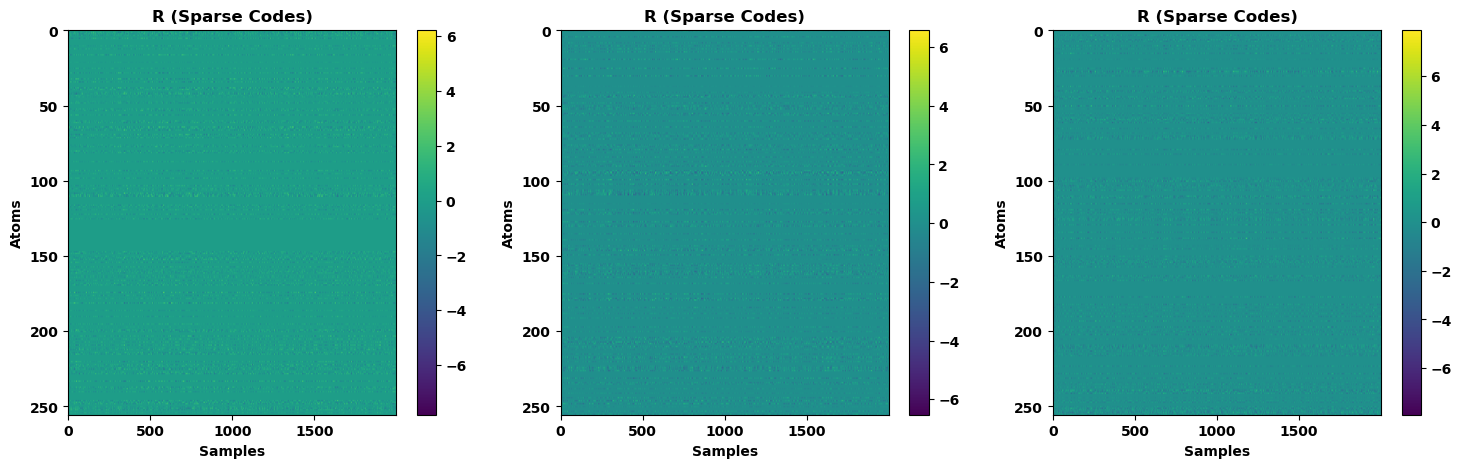

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sparse codes
im0 = axes[0].imshow(S_list[0].detach().cpu().numpy(), aspect="auto", cmap="viridis")
axes[0].set_title("R (Sparse Codes)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Atoms")
plt.colorbar(im0, ax=axes[0])

# Sparse codes
im1 = axes[1].imshow(S_list[1].detach().cpu().numpy(), aspect="auto", cmap="viridis")
axes[1].set_title("R (Sparse Codes)")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Atoms")
plt.colorbar(im1, ax=axes[1])


# Sparse codes
im2 = axes[2].imshow(S_list[2].detach().cpu().numpy(), aspect="auto", cmap="viridis")
axes[2].set_title("R (Sparse Codes)")
axes[2].set_xlabel("Samples")
axes[2].set_ylabel("Atoms")
plt.colorbar(im2, ax=axes[2])